# Imports
Import required libraries and custom modules for the inventory control experiment.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from environments.inventory_control import InventoryControlEnv
from function_approximation.linear_fa import LinearFA
from algorithms.rpi import RPI
from algorithms.crpi import CRPI
from utils import solve_tabular_pi

# Define Inventory Control Environment
Set up the inventory control problem, including state space, action space, and environment parameters.

In [9]:
gamma = 0.9
iters = 50
d_features = 75
n_seeds = 10  # Number of seeds for averaging

# Create environment
env = InventoryControlEnv(M=49)
P, R = env.get_mdp_matrices()
SA = P.shape[0] * P.shape[1]
nu = np.ones((SA, 1)) / SA

# Get the true optimal baseline using Tabular PI
_, Q_opt = solve_tabular_pi(env, gamma)
optimal_return = (nu.T @ Q_opt).item()

# Run RPI and CRPI on Inventory Control
Train both algorithms on the inventory control environment and collect performance metrics.

In [11]:
rpi_all_true, crpi_all_true = [], []
rpi_seed0_true, rpi_seed0_est = None, None
crpi_seed0_true, crpi_seed0_est = None, None

print(f"Running {n_seeds} seeds for Inventory Control. This may take a moment...")

for seed in range(n_seeds):
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column

    # Train RPI
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    _, _, r_hist = rpi_agent.train(track_metrics=True)
    rpi_all_true.append(r_hist['true_return'])

    # Train CRPI
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    _, _, c_hist = crpi_agent.train(track_metrics=True)
    crpi_all_true.append(c_hist['true_return'])

    if seed == 0:
        rpi_seed0_true = r_hist['true_return']
        rpi_seed0_est = r_hist['est_return']
        crpi_seed0_true = c_hist['true_return']
        crpi_seed0_est = c_hist['est_return']

rpi_all_true = np.array(rpi_all_true)
crpi_all_true = np.array(crpi_all_true)

Running 10 seeds for Inventory Control. This may take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration

# Visualize and Compare Results
Plot the learning curves and aggregate performance for RPI and CRPI, and display summary metrics.

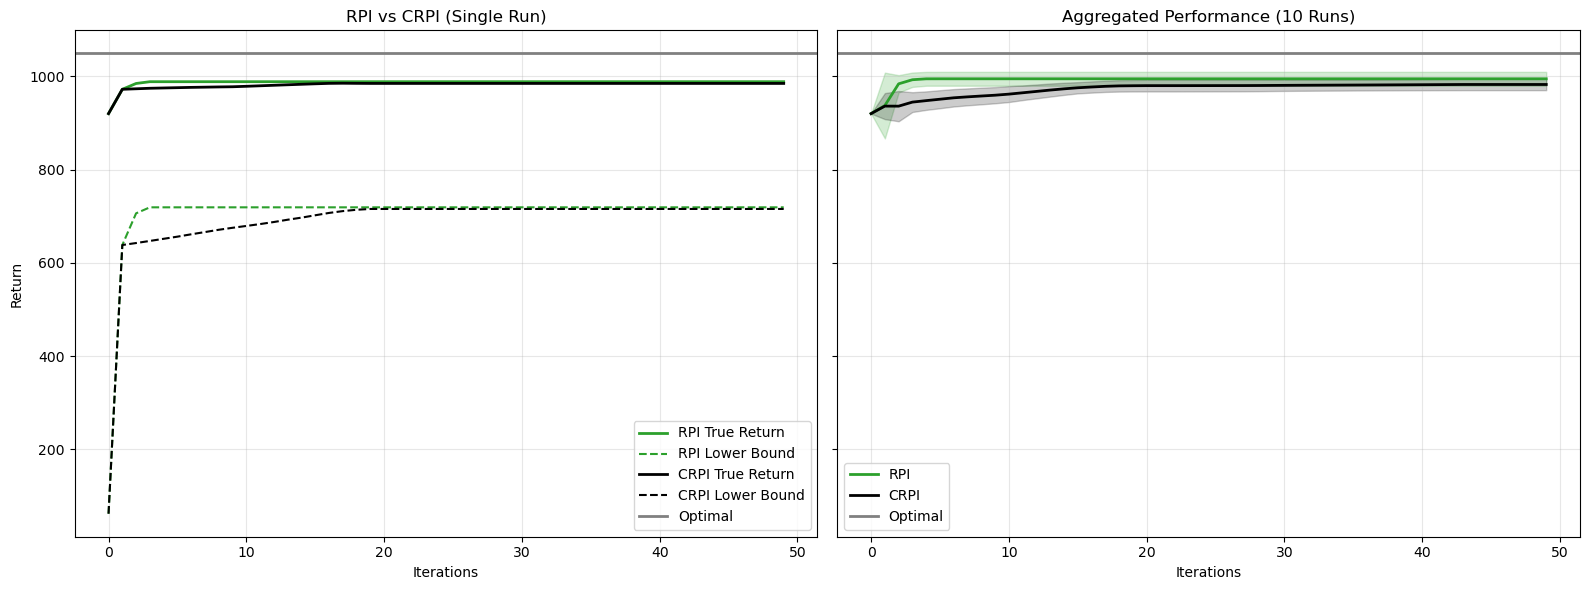

,Algorithm,AUC (mean ± std),Terminal Perf. (mean ± std)
0,RPI,48636.1 ± 738.2,994.77 ± 14.85
1,CRPI,47680.7 ± 573.2,982.57 ± 12.24


In [12]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Subplot 1: Single Run (RPI vs CRPI overlay)
ax1.plot(rpi_seed0_true, color='#2ca02c', label='RPI True Return', linewidth=2)
ax1.plot(rpi_seed0_est, color='#2ca02c', linestyle='--', label='RPI Lower Bound')
ax1.plot(crpi_seed0_true, color='#000000', label='CRPI True Return', linewidth=2)
ax1.plot(crpi_seed0_est, color='#000000', linestyle='--', label='CRPI Lower Bound')
ax1.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax1.set_title("RPI vs CRPI (Single Run)")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Return")
ax1.legend()
ax1.grid(alpha=0.3)

# Subplot 2: Aggregated Performance (Mean ± 1 Std Dev)
rpi_mean = np.mean(rpi_all_true, axis=0)
rpi_std = np.std(rpi_all_true, axis=0)
crpi_mean = np.mean(crpi_all_true, axis=0)
crpi_std = np.std(crpi_all_true, axis=0)

ax2.plot(rpi_mean, color='#2ca02c', label='RPI', linewidth=2)
ax2.fill_between(range(iters), rpi_mean - rpi_std, rpi_mean + rpi_std, color='#2ca02c', alpha=0.2)
ax2.plot(crpi_mean, color='#000000', label='CRPI', linewidth=2)
ax2.fill_between(range(iters), crpi_mean - crpi_std, crpi_mean + crpi_std, color='#000000', alpha=0.2)
ax2.axhline(optimal_return, color='gray', linewidth=2, label='Optimal')

ax2.set_title(f"Aggregated Performance ({n_seeds} Runs)")
ax2.set_xlabel("Iterations")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Metrics Table using trapezoid
rpi_aucs = [np.trapezoid(run) for run in rpi_all_true]
crpi_aucs = [np.trapezoid(run) for run in crpi_all_true]

data = {
    "Algorithm": ["RPI", "CRPI"],
    "AUC (mean ± std)": [f"{np.mean(rpi_aucs):.1f} ± {np.std(rpi_aucs):.1f}",
                         f"{np.mean(crpi_aucs):.1f} ± {np.std(crpi_aucs):.1f}"],
    "Terminal Perf. (mean ± std)": [f"{rpi_mean[-1]:.2f} ± {rpi_std[-1]:.2f}",
                                    f"{crpi_mean[-1]:.2f} ± {crpi_std[-1]:.2f}"]
}
df = pd.DataFrame(data)
display(df)

Running 6 detailed runs. This will take a moment...
RPI Iteration 1/50 completed.
RPI Iteration 2/50 completed.
RPI Iteration 3/50 completed.
RPI Iteration 4/50 completed.
RPI Iteration 5/50 completed.
RPI Iteration 6/50 completed.
RPI Iteration 7/50 completed.
RPI Iteration 8/50 completed.
RPI Iteration 9/50 completed.
RPI Iteration 10/50 completed.
RPI Iteration 11/50 completed.
RPI Iteration 12/50 completed.
RPI Iteration 13/50 completed.
RPI Iteration 14/50 completed.
RPI Iteration 15/50 completed.
RPI Iteration 16/50 completed.
RPI Iteration 17/50 completed.
RPI Iteration 18/50 completed.
RPI Iteration 19/50 completed.
RPI Iteration 20/50 completed.
RPI Iteration 21/50 completed.
RPI Iteration 22/50 completed.
RPI Iteration 23/50 completed.
RPI Iteration 24/50 completed.
RPI Iteration 25/50 completed.
RPI Iteration 26/50 completed.
RPI Iteration 27/50 completed.
RPI Iteration 28/50 completed.
RPI Iteration 29/50 completed.
RPI Iteration 30/50 completed.
RPI Iteration 31/50 complet

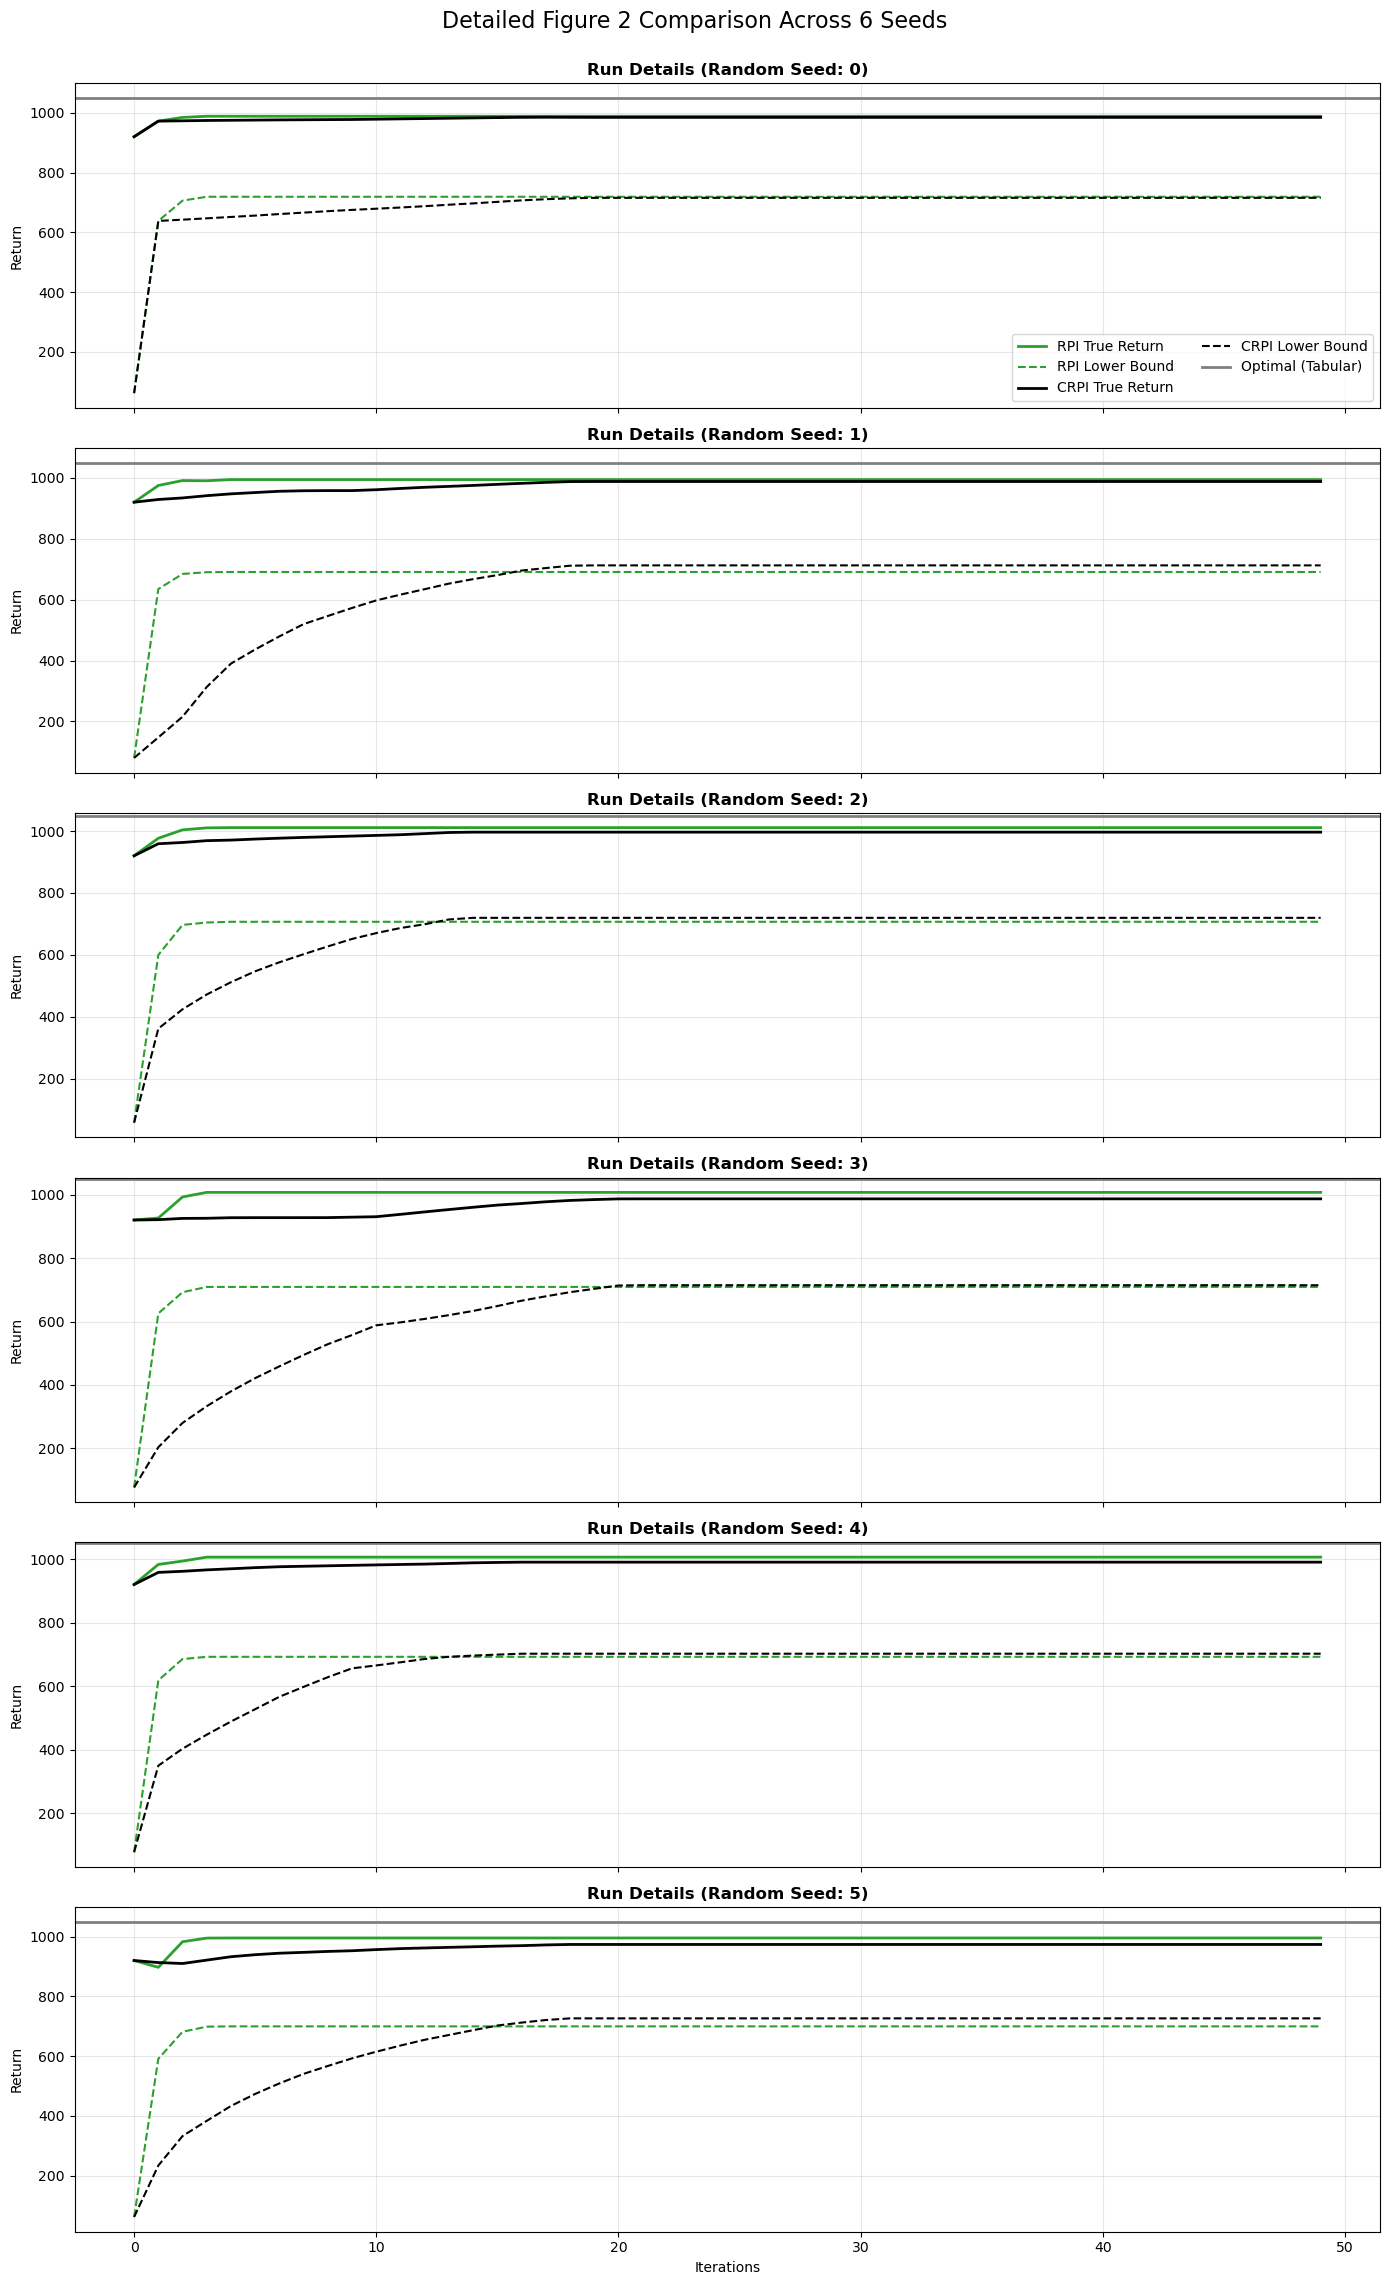

------------------------------
Average Terminal Performance across 6 Runs:
RPI: 1000.527
CRPI: 986.779


In [13]:
# --- CELL 3 ---
n_seeds = 6
# Store metrics for output
rpi_terminals = []
crpi_terminals = []

# Create a 5x1 grid of stacked subplots
fig, axes = plt.subplots(n_seeds, 1, figsize=(14, 4 * n_seeds), sharex=True)
fig.suptitle(f"Detailed Figure 2 Comparison Across {n_seeds} Seeds", fontsize=16)

print(f"Running {n_seeds} detailed runs. This will take a moment...")

# Loop through each seed to train and plot immediately
for i in range(n_seeds):
    seed = i  # Keep seed consistent with index
    ax = axes[i]  # Get the current subplot

    # -- Fixed-Seed Feature Generation --
    np.random.seed(seed)
    Phi = np.random.uniform(1, 5, size=(SA, d_features))
    Phi[:, 0] = 1.0  # Bias column fix

    # -- 1. Train RPI --
    rpi_agent = RPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, rpi_hist = rpi_agent.train(track_metrics=True)
    rpi_terminals.append(rpi_hist['true_return'][-1])

    # -- 2. Train CRPI --
    crpi_agent = CRPI(env, LinearFA(Phi), gamma, iters)
    # Refactored train call, extracting history
    _, _, crpi_hist = crpi_agent.train(track_metrics=True)
    crpi_terminals.append(crpi_hist['true_return'][-1])

    # -- 3. Plotting Subplot (Strict Figure 2 Template) --
    # Plot RPI (Solid True, Dotted Estimated)
    ax.plot(rpi_hist['true_return'], color='#2ca02c', label='RPI True Return', linewidth=2)
    ax.plot(rpi_hist['est_return'], color='#2ca02c', linestyle='--', label='RPI Lower Bound')

    # Plot CRPI (Solid True, Dotted Estimated)
    ax.plot(crpi_hist['true_return'], color='#000000', label='CRPI True Return', linewidth=2)
    ax.plot(crpi_hist['est_return'], color='#000000', linestyle='--', label='CRPI Lower Bound')

    # Plot Optimal Baseline
    ax.axhline(optimal_return, color='gray', linewidth=2, linestyle='-', label='Optimal (Tabular)')

    # Labels and formatting for each subplot
    ax.set_title(f"Run Details (Random Seed: {seed})", fontweight='bold')
    ax.set_ylabel("Return")
    ax.grid(alpha=0.3)

    # Add legend only to the first subplot to reduce clutter
    if i == 0:
        ax.legend(loc='lower right', ncol=2)

# Set common x-label
axes[-1].set_xlabel("Iterations")

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to fit main title
plt.show()

# -- 4. Output Summary Metrics --
print("-" * 30)
print(f"Average Terminal Performance across {n_seeds} Runs:")
print(f"RPI: {np.mean(rpi_terminals):.3f}")
print(f"CRPI: {np.mean(crpi_terminals):.3f}")